In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic Survival Prediction.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [5]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1812/172848211.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [6]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [7]:
df['CabinPresent'] = df['Cabin'].notnull().astype(int)

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [14]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,1
FamilySize,0
CabinPresent,0
Sex_male,0
Embarked_Q,0


In [15]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Fare,1


In [16]:
# Fill numeric columns with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

Logistic Regression: 1.0
Random Forest: 1.0


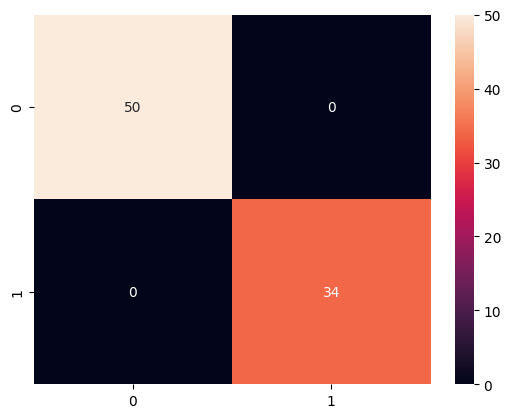

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

         Feature  Importance
7       Sex_male    0.456112
14      Title_Mr    0.212039
13    Title_Miss    0.135488
15     Title_Mrs    0.101053
12  Title_Master    0.027812
1            Age    0.015656
4           Fare    0.014990
5     FamilySize    0.012291
3          Parch    0.005218
17     Title_Rev    0.003644


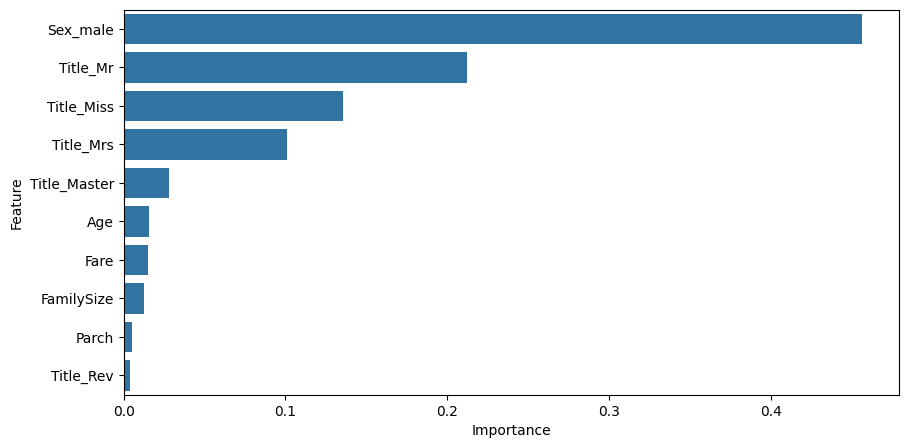

In [26]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

In [27]:
import joblib

joblib.dump(rf, 'titanic_model.pkl')

['titanic_model.pkl']

In [28]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("Prediction:", prediction[0])

Prediction: 0


In [29]:
from google.colab import files

files.download('titanic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>